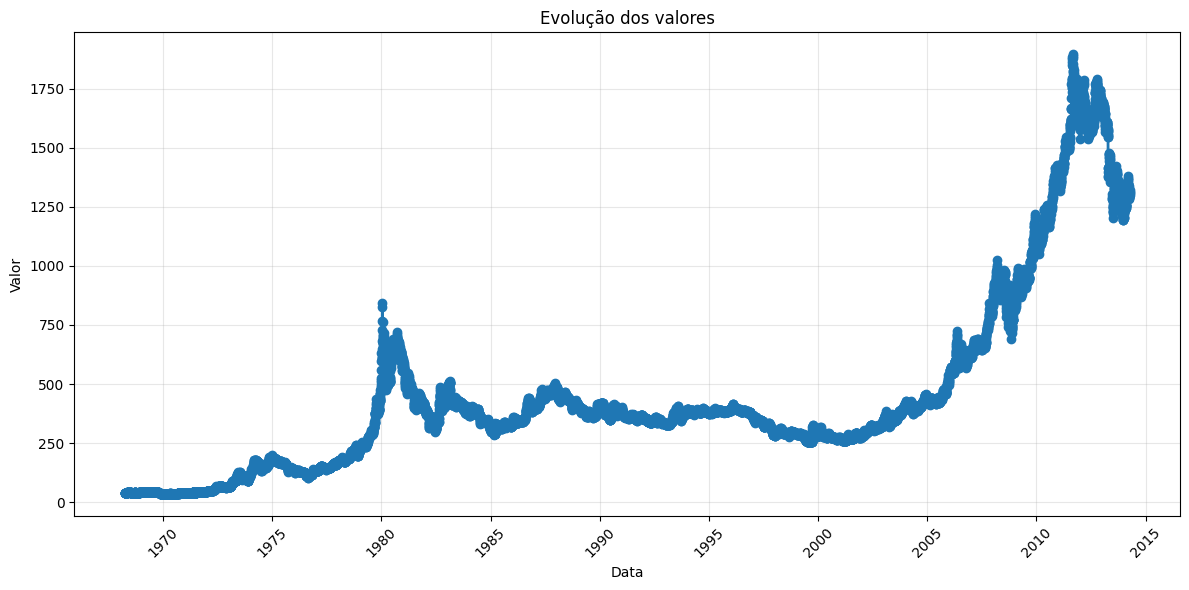

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Ler o arquivo CSV
df = pd.read_csv(
    "bases/grupo5-tratamento/gold_daily_prices.csv",
    sep=";",
    na_values=["NaN"]
)

# Converter DATE para datetime
df["DATE"] = pd.to_datetime(df["DATE"])

# Converter VALUE para número
df["VALUE"] = pd.to_numeric(df["VALUE"], errors="coerce")

# Criar o gráfico
plt.figure(figsize=(12, 6))

plt.plot(
    df["DATE"],
    df["VALUE"],
    marker="o",
    linewidth=2
)

plt.title("Evolução dos valores")
plt.xlabel("Data")
plt.ylabel("Valor")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import holidays

# ==========================================
# 1. Ler a base
# ==========================================

df = pd.read_csv(
    "bases/grupo5-tratamento/gold_daily_prices.csv",
    sep=";",
    na_values=["NaN"]
)

# ==========================================
# 2. Ajustar os tipos
# ==========================================

df["DATE"] = pd.to_datetime(df["DATE"])
df["VALUE"] = pd.to_numeric(df["VALUE"], errors="coerce")

# ==========================================
# 3. Criar lista de feriados brasileiros
#    de 1968 até 2015
# ==========================================

feriados = holidays.Brazil(
    years=range(1968, 2016)
)

# ==========================================
# 4. TARGET 1 - É feriado?
# ==========================================

df["IS_HOLIDAY"] = df["DATE"].isin(feriados).astype(int)

# ==========================================
# 5. TARGET 2 - O preço aumenta no dia seguinte?
# ==========================================

df["TARGET_UP"] = (
    df["VALUE"].shift(-1) > df["VALUE"]
).astype("Int64")

# ==========================================
# 6. Visualizar
# ==========================================

print(df.head(20))

         DATE  VALUE  IS_HOLIDAY  TARGET_UP
0  1968-04-01  38.00           0          0
1  1968-04-02  37.60           0          1
2  1968-04-03  37.70           0          0
3  1968-04-04  36.70           0          1
4  1968-04-05  37.20           0          0
5  1968-04-08  37.00           0          1
6  1968-04-09  37.25           0          1
7  1968-04-10  37.60           0          1
8  1968-04-11  38.05           0          0
9  1968-04-12    NaN           1          0
10 1968-04-15    NaN           0          0
11 1968-04-16  38.10           0          0
12 1968-04-17  38.00           0          0
13 1968-04-18  37.60           0          1
14 1968-04-19  37.65           0          1
15 1968-04-22  38.30           0          0
16 1968-04-23  38.05           0          1
17 1968-04-24  38.35           0          0
18 1968-04-25  38.25           0          1
19 1968-04-26  38.50           0          1


C:\Users\guilhermepinheiro-ie\AppData\Local\Temp\ipykernel_28120\2176957667.py:35: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df["IS_HOLIDAY"] = df["DATE"].isin(feriados).astype(int)


In [11]:
df.to_csv(
    "analyses/grupo5/01_dados/outputs/gold_daily_prices_targets.csv",
    sep=";",
    index=False
)